In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("airbnb-data.csv");

#from the info, reviews per month has a lot of NAN values
data['reviews_per_month'] = data['reviews_per_month'].fillna(0);

#replace all nan values in name with unknown
data['name'] = data['name'].fillna("Unknown");

#drop the id and host_name columns because they aren't really needed here
data.drop(['id', 'host_name'], axis=1, inplace=True);

#removes outliers which will lead to a right skewed distribution
data = data[data['price'] < 500]

data

,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,Skylit Midtown Castle,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,THE VILLAGE OF HARLEM....NEW YORK !,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.00,1,365
3,Cozy Entire Floor of Brownstone,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Entire Apt: Spacious Studio/Loft by central park,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,Charming one bedroom - newly renovated rowhouse,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,0.00,2,9
48891,Affordable room in Bushwick/East Williamsburg,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,0.00,2,36
48892,Sunny Studio at Historical Neighborhood,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,0.00,1,27
48893,43rd St. Time Square-cozy single bed,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,0.00,6,2


# Price Distribution

Most Airbnb listings are low to mid-priced, with some expensive outliers which were filtered out to avoid skewing the data.

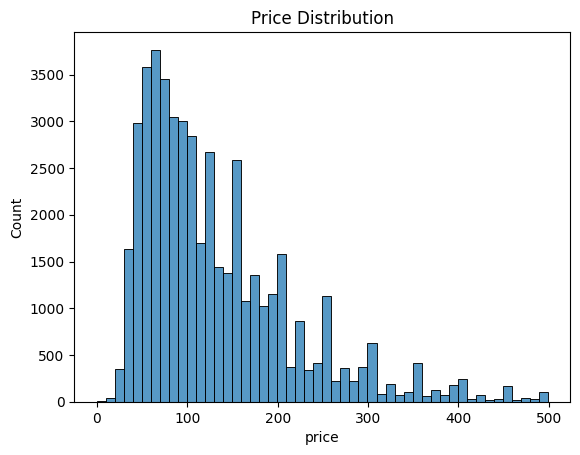

In [10]:
sns.histplot(data['price'], bins=50)
plt.title("Price Distribution")
plt.show()

# Price by neighbourhood

Sorts the prices of Airbnb's in different neighbourhoods. Manhattan is the most expensive

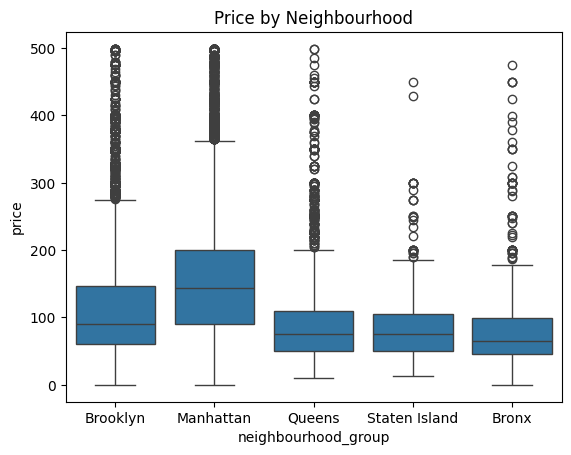

In [11]:
sns.boxplot(x='neighbourhood_group', y='price', data=data)
plt.title("Price by Neighbourhood")
plt.show()

# Room Type Distribution

Entire homes and apartments are the most common listing type, followed by private rooms. Shared rooms are very rare with less than 5000 listings.

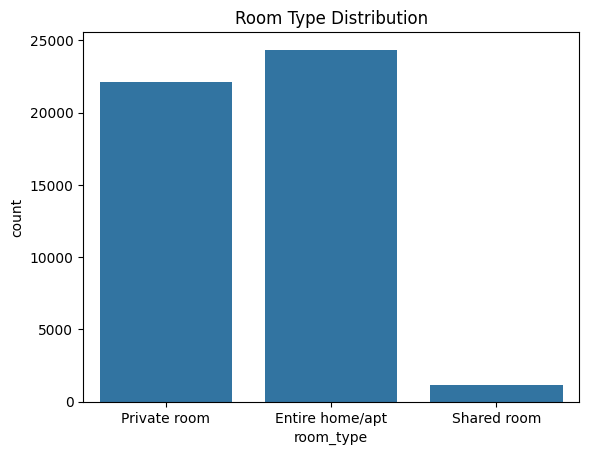

In [12]:
sns.countplot(x='room_type', data=data)
plt.title("Room Type Distribution")
plt.show()